# Add metadata to epochs

In [21]:
import mne
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# importing from your local utils
import sys
sys.path.append("../scripts")
from params import fnames, L_FREQ, H_FREQ, FILT_METHOD

Load the epochs! It is important that these where created with `reject = None` so the events match up with the behavioural data!


In [22]:
subject="0195"

epochs_path = fnames.sub_filtered_ica_epochs(subject=subject, l_freq=L_FREQ, h_freq=H_FREQ, method=FILT_METHOD)
epochs = mne.read_epochs(epochs_path)

Reading /work/LauraBockPaulsen#1941/derivatives/MEG/0195/0195_filtered_0.1-40_fir_ICA_meg-epo.fif ...
    Read a total of 9 projection items:
        planar-Raw-0.000-120.000-PCA-01 (1 x 203) active
        planar-Raw-0.000-120.000-PCA-02 (1 x 203) active
        planar-Raw-0.000-120.000-PCA-03 (1 x 203) active
        axial-Raw-0.000-120.000-PCA-01 (1 x 102) active
        axial-Raw-0.000-120.000-PCA-02 (1 x 102) active
        axial-Raw-0.000-120.000-PCA-03 (1 x 102) active
        axial-Raw-0.000-120.000-PCA-04 (1 x 102) active
        axial-Raw-0.000-120.000-PCA-05 (1 x 102) active
        axial-Raw-0.000-120.000-PCA-06 (1 x 102) active
    Found the data of interest:
        t =    -200.00 ...     696.00 ms
        0 CTF compensation matrices available
Adding metadata with 13 columns
2400 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 9)
9 projection items activated


Now let's load the behavioural data!

In [23]:
behav_path = fnames.sub_behav(subject=subject)
behav_data = pd.read_csv(behav_path)

We want to make sure that our behavioural data and our epochs match in length, so each row in the behavoural data corresponds to one epoch

In [24]:
print(len(epochs), len(behav_data))
behav_data.head()

2400 600


,subject,trial_number,staircase_number,fixation_duration_ms,target_duration_ms,target_type,target_contrast,mask_duration_ms,objective_response,objective_response_time_ms,subjective_response,subjective_response_time_ms
0,195,0,0,583.333333,33.333333,stimulus_1,0.400000,33.333333,stimulus_1,0.510027,2,0.513425
1,195,1,0,533.333333,33.333333,stimulus_0,0.259812,33.333333,stimulus_0,0.534131,2,0.905663
2,195,2,0,641.666667,33.333333,stimulus_0,0.169089,33.333333,stimulus_0,1.130867,1,1.094187
3,195,3,0,541.666667,33.333333,stimulus_1,0.097917,33.333333,stimulus_1,1.005263,2,1.000203
4,195,4,0,733.333333,33.333333,stimulus_0,0.038160,33.333333,stimulus_0,1.277378,1,1.344440


We can see, that each trial (including presentation of gabor patch, mask, response and subjective rating) has one row. However, we have four triggers, and therefore four epochs for each row in the behavioural data. We can solve this, by copying each row four times. I'll also add a column, indicating whether it is the target, mask or response. 

In [25]:
# Repeat each behavioral row 4 times
behav_data_expanded = behav_data.loc[
    behav_data.index.repeat(4)
].reset_index(drop=True)

# Add epoch type, repeating the sequence for every trial
behav_data_expanded["epoch_type"] = [
    epoch_type
    for _ in range(len(behav_data))
    for epoch_type in ["target", "mask", "response", "PAS_rating"]
]

# Check the result
print(len(behav_data_expanded))
behav_data_expanded.head(9)

2400


,subject,trial_number,staircase_number,fixation_duration_ms,target_duration_ms,target_type,target_contrast,mask_duration_ms,objective_response,objective_response_time_ms,subjective_response,subjective_response_time_ms,epoch_type
0,195,0,0,583.333333,33.333333,stimulus_1,0.400000,33.333333,stimulus_1,0.510027,2,0.513425,target
1,195,0,0,583.333333,33.333333,stimulus_1,0.400000,33.333333,stimulus_1,0.510027,2,0.513425,mask
2,195,0,0,583.333333,33.333333,stimulus_1,0.400000,33.333333,stimulus_1,0.510027,2,0.513425,response
3,195,0,0,583.333333,33.333333,stimulus_1,0.400000,33.333333,stimulus_1,0.510027,2,0.513425,PAS_rating
4,195,1,0,533.333333,33.333333,stimulus_0,0.259812,33.333333,stimulus_0,0.534131,2,0.905663,target
5,195,1,0,533.333333,33.333333,stimulus_0,0.259812,33.333333,stimulus_0,0.534131,2,0.905663,mask
6,195,1,0,533.333333,33.333333,stimulus_0,0.259812,33.333333,stimulus_0,0.534131,2,0.905663,response
7,195,1,0,533.333333,33.333333,stimulus_0,0.259812,33.333333,stimulus_0,0.534131,2,0.905663,PAS_rating
8,195,2,0,641.666667,33.333333,stimulus_0,0.169089,33.333333,stimulus_0,1.130867,1,1.094187,target


In [26]:
epochs.metadata = behav_data_expanded

# verifying that it went well!
targets = epochs["gabor"]
targets.metadata["epoch_type"].unique()

# we see we only have targets! nice

Replacing existing metadata with 13 columns


<StringArray>
['target']
Length: 1, dtype: str

# What is this useful for?
Now we can use this to get epochs with a for example a specific PAS score!

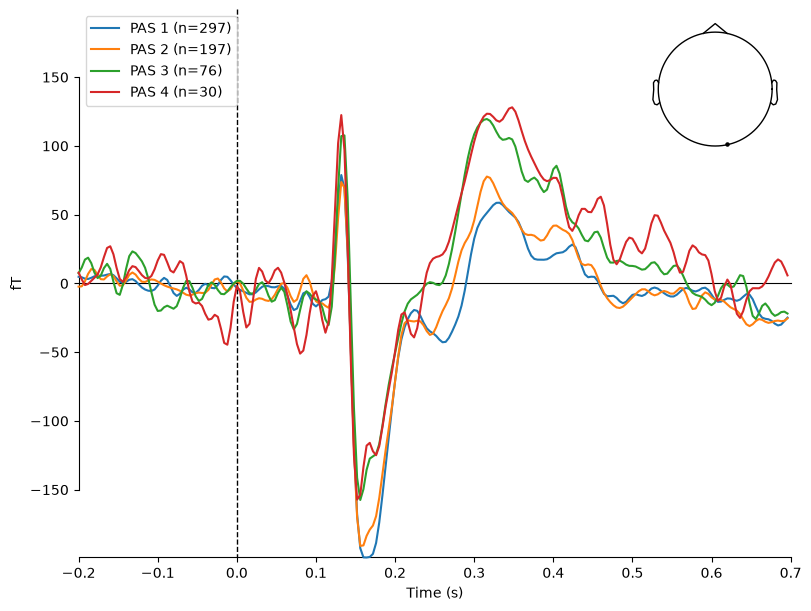

In [27]:
target_pas1 = targets[targets.metadata["subjective_response"]==1]
target_pas2 = targets[targets.metadata["subjective_response"]==2]
target_pas3 = targets[targets.metadata["subjective_response"]==3]
target_pas4 = targets[targets.metadata["subjective_response"]==4]

chs = ["MEG2031"]

target_pas1_evo = target_pas1.average(picks=chs)
target_pas2_evo = target_pas2.average(picks=chs)
target_pas3_evo = target_pas3.average(picks=chs)
target_pas4_evo = target_pas4.average(picks=chs)

mne.viz.plot_compare_evokeds({
    f"PAS 1 (n={len(target_pas1)})": target_pas1_evo,
    f"PAS 2 (n={len(target_pas2)})": target_pas2_evo,
    f"PAS 3 (n={len(target_pas3)})": target_pas3_evo,
    f"PAS 4 (n={len(target_pas4)})": target_pas4_evo
    },
);


If you want to see even more ways to take advantage of the metadata, you can have a look at [this page](https://mne.tools/stable/auto_tutorials/epochs/30_epochs_metadata.html) from the documentation of MNE. 